In [54]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.ticker as ticker
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import (MultipleLocator, FormatStrFormatter,
                               AutoMinorLocator)
plt.rcParams.update({'font.size': 12})
import seaborn as sns
import cmath
import math 
from numpy.linalg import inv

plt.rcParams['xtick.labelsize'] = 30  # Set font size for x-axis tick labels
plt.rcParams['ytick.labelsize'] = 30  # Set font size for y-axis tick labels

def custom_plot_single(fig, ax1, 
                       x_lst, y_lst, label_lst, xlim, ylim, label,pltname,
                       color=['k','r','b','g','o','c','m','y'],
                       linestyle=['solid','dashed','solid','dashed','solid','dashed'],
                       markertype=[None,None,'o','^','o','^'],
                       fillstyle=['none','none','none','none','full','full'],
                       linewidth=20*[3],
                       markevery=[450,30,50,40,56,72,63,95],
                       show_legend=True,
                       plt_outside=False, y_logscale = False):
    
    fig.patch.set_facecolor('white')
    ax1.patch.set_facecolor('white')
    #color[len(x_lst)-1] = 'gray'
    for p in range(0, len(x_lst)):
        ax1.plot(x_lst[p], y_lst[p], color[p],
                 linewidth=linewidth[p],
                 linestyle=linestyle[p],
                 marker=markertype[p],
                 fillstyle=fillstyle[p],
                 markevery=markevery[p],
                 markersize=8,
                 label=label_lst[p])
    if(show_legend):
        ax1.legend(prop={'size': 24},loc='best')
    ax1.tick_params(which='minor', width=2, length=4, color='k')
    ax1.tick_params(which='major', width=2, length=8, color='k')

    #ax1.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    #ax1.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    if(show_legend):
        ax1.legend(prop={'size': 18},loc='best',shadow=True,bbox_to_anchor=(1.01,1.0))
    if (y_logscale):
        ax1.set_yscale('log')
    ax1.set_ylim(ylim[0],ylim[1])
    ax1.set_xlim(xlim[0],xlim[1])
    ax1.set_xlabel(label[0], fontsize=30)#, fontdict=dict(weight='bold'))
    ax1.set_ylabel(label[1], fontsize=30)#, fontdict=dict(weight='bold'))
    fontsize=30
    for tick in ax1.xaxis.get_major_ticks():
        tick.label1.set_fontsize(fontsize)

    for tick in ax1.yaxis.get_major_ticks():
        tick.label1.set_fontsize(fontsize)
    for spine in ax1.spines.values():
        spine.set_linewidth(2)  # Increase the frame thickness             
    if(plt_outside==False):
        plt.savefig(pltname, bbox_inches = "tight")
    return plt,pltname

PrintFigures=True
PointCharge=True


In [2]:
import pandas as pd
folder_path = '../figures_exp/'
Fig1d = pd.read_csv(folder_path  + 'fig1d.csv', header=None)

Vgs_exp  = Fig1d[0].to_numpy()
Ids_exp  = Fig1d[1].to_numpy() 


In [3]:
#quantum of conductance
#https://physics.nist.gov/cgi-bin/cuu/Value?conqu2e2sh
#G_quantum=2e^2/h, q=1.602e-19, h = 6.62607e-34

G_quantum  = 7.748091729e-5 #[S] 

num_CNTs = 1
Vds = 0.1
CNT_spacing = 2.556e-3
micron = 1e-6
nano=1e-9

CNTs_per_micron = micron/CNT_spacing
pts_max  = 64

m=20
n=0
acc = 0.142e-9
gamma=2.5 #eV
Temp = 298.
def get_radius(acc,m,n):
    return acc*(np.sqrt(3.)/(2*np.pi))*np.sqrt(m**2 + m*n + n**2)
    
R_cnt = get_radius(acc,m,n)
print('Radius of CNT (nm):', R_cnt/nano)

Eg_min = acc*gamma/R_cnt
print('bandgap, Eg_min/(eV):', Eg_min)

Radius of CNT (nm): 0.7828870314989447
bandgap, Eg_min/(eV): 0.45344984105855446


In [5]:
variable_occupation = []
foldername = [] 
label_str = []
Color = []
label_str.append(r'Experiment, $E_f=-1$')
Color.append('red')

rhop_3D = []
rhop_2D = []
foldername.append('../periodic/with_point_charge/no_charge/EfmDot2')
label_str.append(r'$E_f=-0.2$, $\rho_p=0$')
Color.append('k')
variable_occupation.append(False)
rhop_3D.append(0) # for base case of 0 trap
rhop_2D.append(0) # for base case of 0 trap


start_3D=1
foldername.append('../periodic/with_point_charge/density_variation_3D/rhoDot1')
label_str.append(r'(3D) $\rho_p = 0.1$ e/nm$^3$')
Color.append('b')
variable_occupation.append(True)
rhop_3D.append(0.1) 

foldername.append('../periodic/with_point_charge/density_variation_3D/rhoDot2')
label_str.append(r'(3D) $\rho_p = 0.2$ e/nm$^3$')
Color.append('b')
variable_occupation.append(True)
rhop_3D.append(0.2) 

foldername.append('../periodic/with_point_charge/density_variation_3D/rhoDot3')
label_str.append(r'(3D) $\rho_p = 0.3$ e/nm$^3$')
Color.append('b')
variable_occupation.append(True)
rhop_3D.append(0.3) 

foldername.append('../periodic/with_point_charge/density_variation_3D/rhoDot4')
label_str.append(r'(3D) $\rho_p = 0.4$ e/nm$^3$')
Color.append('b')
variable_occupation.append(True)
rhop_3D.append(0.4) 

foldername.append('../periodic/with_point_charge/density_variation_3D/rhoDot5')
label_str.append(r'(3D) $\rho_p = 0.5$ e/nm$^3$')
Color.append('b')
variable_occupation.append(True)
rhop_3D.append(0.5) 

foldername.append('../periodic/with_point_charge/density_variation_3D/rhoDot6')
label_str.append(r'(3D) $\rho_p = 0.6$ e/nm$^3$')
Color.append('b')
variable_occupation.append(True)
rhop_3D.append(0.6) 

foldername.append('../periodic/with_point_charge/density_variation_3D/rhoDot7')
label_str.append(r'(3D) $\rho_p = 0.7$ e/nm$^3$')
Color.append('cyan')
variable_occupation.append(True)
rhop_3D.append(0.7) 

end_3D=start_3D+7

foldername.append('../periodic/with_point_charge/density_variation_2D/rhoDot2')
label_str.append(r'(2D) $\rho_p = 0.2$ e/nm$^2$')
Color.append('g')
variable_occupation.append(True)
rhop_2D.append(0.2) 

foldername.append('../periodic/with_point_charge/density_variation_2D/rhoDot4')
label_str.append(r'(2D) $\rho_p = 0.4$ e/nm$^2$')
Color.append('g')
variable_occupation.append(True)
rhop_2D.append(0.4)

foldername.append('../periodic/with_point_charge/density_variation_2D/rhoDot6')
label_str.append(r'(2D) $\rho_p = 0.6$ e/nm$^2$')
Color.append('g')
variable_occupation.append(True)
rhop_2D.append(0.6)

foldername.append('../periodic/with_point_charge/density_variation_2D/rhoDot8')
label_str.append(r'(2D) $\rho_p = 0.8$ e/nm$^2$')
Color.append('g')
variable_occupation.append(True)
rhop_2D.append(0.8)

foldername.append('../periodic/with_point_charge/density_variation_2D/rho1')
label_str.append(r'(2D) $\rho_p = 1$ e/nm$^2$')
Color.append('g')
variable_occupation.append(True)
rhop_2D.append(1)

foldername.append('../periodic/with_point_charge/density_variation_2D/rho1Dot2')
label_str.append(r'(2D) $\rho_p = 1.2$ e/nm$^2$')
Color.append('g')
variable_occupation.append(True)
rhop_2D.append(1.2)

foldername.append('../periodic/with_point_charge/density_variation_2D/rho1Dot4')
label_str.append(r'(2D) $\rho_p = 1.4$ e/nm$^2$')
Color.append('g')
variable_occupation.append(True)
rhop_2D.append(1.4)

foldername.append('../periodic/with_point_charge/density_variation_2D/rho1Dot6')
label_str.append(r'(2D) $\rho_p = 1.6$ e/nm$^2$')
Color.append('yellow')
variable_occupation.append(True)
rhop_2D.append(1.6)

end_2D  = end_3D+ 8

num_labels=np.size(label_str)
num_folders=np.size(foldername)
rhop_3D = np.array(rhop_3D)
rhop_2D = np.array(rhop_2D)

print('start_3D', start_3D)
print('end_3D', end_3D)
print('end_2D', end_2D)

print('num_labels', num_labels)
print('num_folders', num_folders)

start_3D 1
end_3D 8
end_2D 16
num_labels 17
num_folders 16


In [6]:
num_folders=np.size(foldername)
Vgs =  np.zeros((num_folders, pts_max),dtype=float)
G   = np.zeros((num_folders, pts_max),dtype=float)
Ids_appx = np.zeros((num_folders, pts_max),dtype=float)
pts = np.zeros(num_folders,dtype=int)
#pts[:] = pts_max

In [7]:
for folder in range(num_folders):
    file_path = f"{foldername[folder]}/negf/NS_1/I.dat"
    print(str(folder) +  str(file_path))

    if(folder==0):
        data = np.loadtxt(file_path, skiprows=1, usecols=(2, 9))  # Vgs = col[2], G = col[9]
    else:
        data = np.loadtxt(file_path, skiprows=1, usecols=(2, 7))  # Vgs = col[2], G = col[7]

    vgs_arr = np.array(data[:, 0])
    g_arr = np.array(data[:, 1])

    pts[folder] = len(vgs_arr)
    Vgs[folder][:pts[folder]] = vgs_arr
    G[folder][:pts[folder]] = g_arr
    Ids_appx[folder] =  G[folder]*G_quantum*Vds/CNT_spacing

0../periodic/with_point_charge/no_charge/EfmDot2/negf/NS_1/I.dat
1../periodic/with_point_charge/density_variation_3D/rhoDot1/negf/NS_1/I.dat
2../periodic/with_point_charge/density_variation_3D/rhoDot2/negf/NS_1/I.dat
3../periodic/with_point_charge/density_variation_3D/rhoDot3/negf/NS_1/I.dat
4../periodic/with_point_charge/density_variation_3D/rhoDot4/negf/NS_1/I.dat
5../periodic/with_point_charge/density_variation_3D/rhoDot5/negf/NS_1/I.dat
6../periodic/with_point_charge/density_variation_3D/rhoDot6/negf/NS_1/I.dat
7../periodic/with_point_charge/density_variation_3D/rhoDot7/negf/NS_1/I.dat
8../periodic/with_point_charge/density_variation_2D/rhoDot2/negf/NS_1/I.dat
9../periodic/with_point_charge/density_variation_2D/rhoDot4/negf/NS_1/I.dat
10../periodic/with_point_charge/density_variation_2D/rhoDot6/negf/NS_1/I.dat
11../periodic/with_point_charge/density_variation_2D/rhoDot8/negf/NS_1/I.dat
12../periodic/with_point_charge/density_variation_2D/rho1/negf/NS_1/I.dat
13../periodic/with_poin

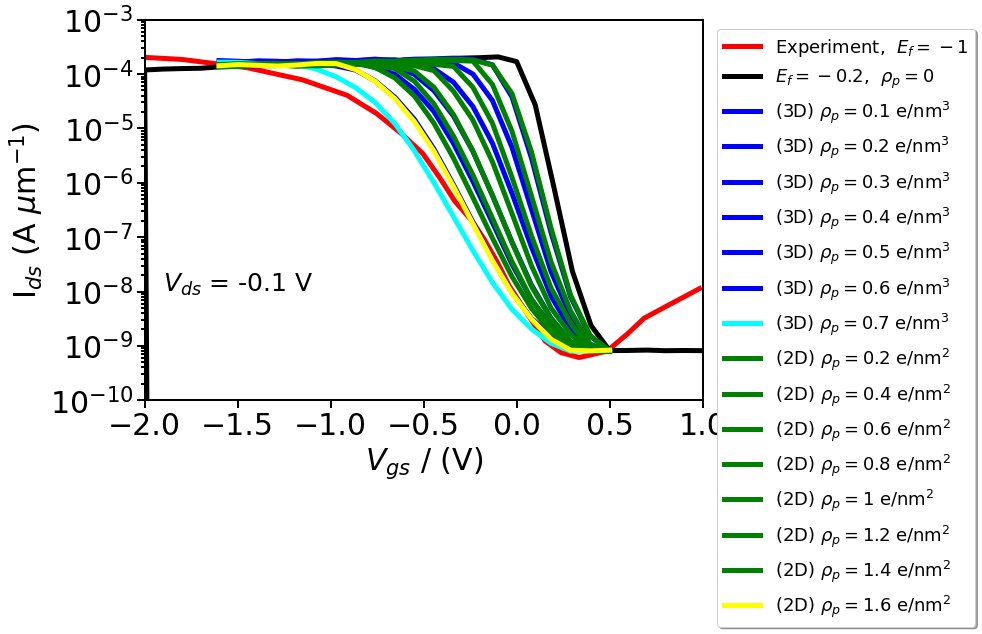

In [8]:
if(PrintFigures): 
    fig, ax = plt.subplots(1,1)
    fig.set_size_inches(10,7)    
    plt,pltname = custom_plot_single(fig,ax,
                                     [Vgs_exp] + [Vgs[0]] + [(Vgs[f][:pts[f]]) for f in range(start_3D, end_3D)]
                                     + [(Vgs[f][:pts[f]]) for f in range(end_3D, end_2D)], 
                                     [Ids_exp] + [Ids_appx[0]] + [Ids_appx[f][:pts[f]] for f in range(start_3D, end_3D)]
                                     + [Ids_appx[f][:pts[f]] for f in range(end_3D, end_2D)],
                                     [', '.join(label_str[folder].split(',')) for folder in range(num_labels)],
                                     [-2, 1],
                                     [1e-10,1e-3],
                                     [r'$V_{gs}$ / (V)',
                                      r'I$_{ds}$ (A $\mu$m$^{-1}$)'],
                                     'G_3D_2D_all.png',
                                     color=Color,
                                     linestyle=['solid']*num_labels,
                                     markertype=[None]*num_labels,
                                     markevery=[1]*num_labels,
                                     linewidth=[5]*num_labels,
                                     fillstyle=['none']*num_labels,                                     
                       show_legend=True,
                       plt_outside=True, y_logscale=True) 
    plt.text(-1.9,1e-8, r'$V_{ds}$ = -0.1 V', fontsize=25, color='k')
    
    plt.savefig(pltname, bbox_inches = "tight", dpi='figure', format='png', pad_inches=0.1, facecolor='auto', edgecolor='auto')
   

In [9]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def plot_all_charges(plt, foldername, variable_occupation, label_str, Color):
    all_Vgs_values = []
    all_total_charge_values = []
    all_fractional_active_charge_values = []
    
    for i, folder in enumerate(foldername):
        #print(i,folder,variable_occupation[i])
        if variable_occupation[i]:
            filename = folder + '/point_charge/total_charge_vs_step.dat'
            steps = []
            Vgs_values = []
            total_charge_values = []
            fractional_active_charge_values = []
            
            with open(filename, 'r') as file:
                lines = file.readlines()[1:]  # Skip the header
                current_step = None
                
                for line in lines:
                    cols = line.split()
                    #print(cols) #for debugging
                    step = int(cols[0])
                    Vgs = float(cols[2])
                    total_charge = float(cols[4])
                    fractional_active_charge = float(cols[5])
                    
                    # Check if the step has changed
                    if step != current_step:
                        if current_step is not None:
                            # Store the last entry before the step change
                            Vgs_values.append(last_Vgs)
                            total_charge_values.append(last_total_charge)
                            fractional_active_charge_values.append(last_fractional_active_charge)
                        current_step = step
                    
                    # Store the last values in the current step
                    last_Vgs = Vgs
                    last_total_charge = total_charge
                    last_fractional_active_charge = fractional_active_charge
                
                # Append the last set of values after the loop ends
                Vgs_values.append(last_Vgs)
                total_charge_values.append(last_total_charge)
                fractional_active_charge_values.append(last_fractional_active_charge)
            
            all_Vgs_values.append(Vgs_values)
            all_total_charge_values.append(total_charge_values)
            all_fractional_active_charge_values.append(fractional_active_charge_values)

    return np.array(all_Vgs_values), np.array(all_total_charge_values), np.array(all_fractional_active_charge_values)

In [10]:
all_Vgs_values, all_total_charge_values, all_fractional_active_charge_values = plot_all_charges(plt, foldername, variable_occupation, label_str, Color)

In [59]:
total_charge_3D = all_total_charge_values[start_3D-1:end_3D-1]
total_charge_2D = all_total_charge_values[end_3D-1:end_2D-1]
fractional_charge_3D = all_fractional_active_charge_values[start_3D-1:end_3D-1]
fractional_charge_2D = all_fractional_active_charge_values[end_3D-1:end_2D-1]
np.shape(total_charge_3D)

(7, 21)

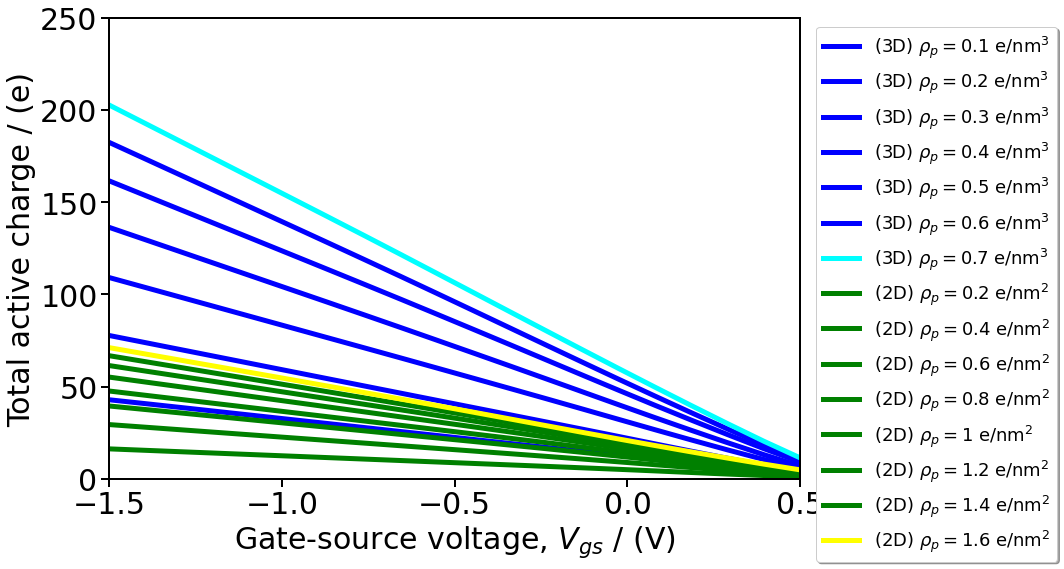

In [62]:
if PrintFigures: 
    fig = plt.figure(figsize=(12,8))
    ax = fig.add_axes([0.18,0.15,0.8,0.8])

    plt,pltname = custom_plot_single(fig, ax,
        x_lst=[(Vgs[f][:pts[f]]) for f in range(start_3D, end_3D)] + [(Vgs[f][:pts[f]]) for f in range(end_3D, end_2D)],
        y_lst=[total_charge_3D[f][:pts[f]] for f in range(np.shape(total_charge_3D)[0])] + [total_charge_2D[f][:pts[f]] for f in range(np.shape(total_charge_2D)[0])],
        label_lst=[', '.join(label_str[folder].split(',')) for folder in range(2,num_labels)],                            
        xlim=[-1.5, 0.5],
        ylim=[0, 250],
        label=['Gate-source voltage, $V_{gs}$ / (V)', 'Total active charge / (e)'],
        pltname='total_charge_3D_2D_all.png',
        color=Color[2:],
        linestyle=[None]*num_labels,
        markertype=[None]*num_labels,
        markevery=[1]*num_labels,
        linewidth=[5]*num_labels,
        fillstyle=['none']*num_labels
    )
    # Adding shaded regions (stddev)
    ax.set_xticks(np.arange(-1.5, 0.6, 0.5))  # X-axis ticks from -1.5 to 0.5 with a step of 0.5
    plt.savefig(pltname, bbox_inches="tight", dpi='figure', format='png', pad_inches=0.1, facecolor='auto', edgecolor='auto')

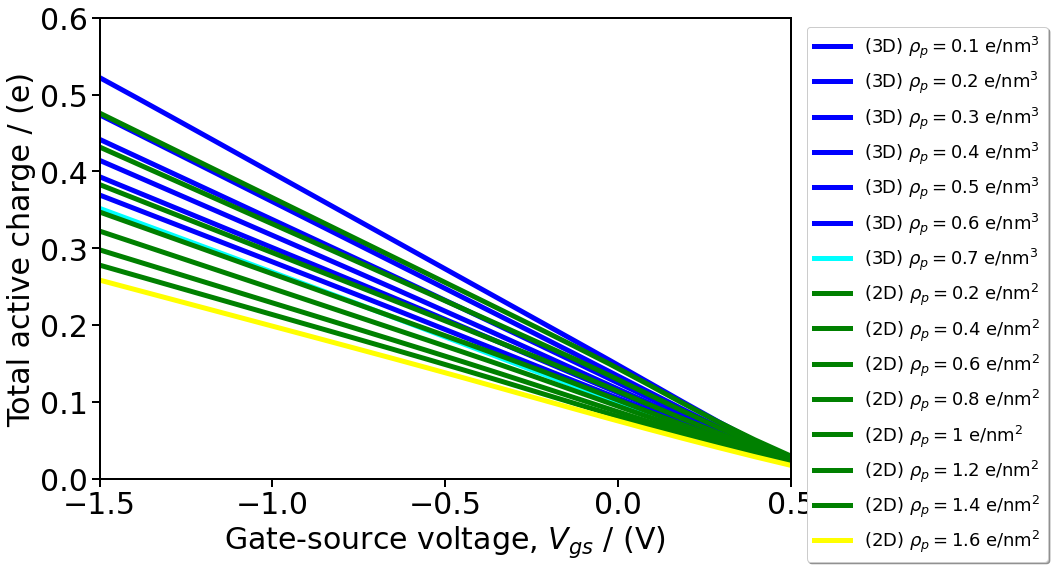

In [63]:
if PrintFigures: 
    fig = plt.figure(figsize=(12,8))
    ax = fig.add_axes([0.18,0.15,0.8,0.8])

    plt,pltname = custom_plot_single(fig, ax,
        x_lst=[(Vgs[f][:pts[f]]) for f in range(start_3D, end_3D)] + [(Vgs[f][:pts[f]]) for f in range(end_3D, end_2D)],
        y_lst=[fractional_charge_3D[f][:pts[f]] for f in range(np.shape(fractional_charge_3D)[0])] + [fractional_charge_2D[f][:pts[f]] for f in range(np.shape(fractional_charge_2D)[0])],
        label_lst=[', '.join(label_str[folder].split(',')) for folder in range(2,num_labels)],                            
        xlim=[-1.5, 0.5],
        ylim=[0, 0.6],
        label=['Gate-source voltage, $V_{gs}$ / (V)', 'Total active charge / (e)'],
        pltname='total_fractional_charge_3D_2D_all.png',
        color=Color[2:],
        linestyle=[None]*num_labels,
        markertype=[None]*num_labels,
        markevery=[1]*num_labels,
        linewidth=[5]*num_labels,
        fillstyle=['none']*num_labels
    )
    # Adding shaded regions (stddev)
    ax.set_xticks(np.arange(-1.5, 0.6, 0.5))  # X-axis ticks from -1.5 to 0.5 with a step of 0.5
    plt.savefig(pltname, bbox_inches="tight", dpi='figure', format='png', pad_inches=0.1, facecolor='auto', edgecolor='auto')

# Compute SS and ON current (per micron)

### First read band structure and find at what voltage is the band edge in the channel kT and 4kT away from the Fermi level.

In [13]:
from scipy.interpolate import interp1d
from scipy.optimize import fsolve

num_rings=1664
E_f = -0.2 #eV
Scaling_Factor = Vds*G_quantum*CNTs_per_micron

In [14]:
print(f"num_folders: {num_folders}, pts_max: {pts_max}, num_rings: {num_rings}")
Y =  np.zeros((num_folders,pts_max,num_rings),dtype=float)
Qout  = np.zeros((num_folders,pts_max,num_rings),dtype=float)
U     = np.zeros((num_folders,pts_max,num_rings),dtype=float)
Ev  = np.zeros((num_folders,pts_max,num_rings),dtype=float)
Ec  = np.zeros((num_folders,pts_max,num_rings),dtype=float)

num_folders: 16, pts_max: 64, num_rings: 1664


In [18]:
for folder in range(num_folders):
    path = foldername[folder] + '/negf/NS_1/step'
    print(f"folder: {folder}, path: {path}")
    
    for f in range(pts[folder]):
        s=f
        fileQout = open(path+"%04d_Qout.dat"%(s))
        #print('fileQout',fileQout)
        lst = []
        counter=0
        for line in fileQout:    
            if (counter > 0 and counter < num_rings+1):
                lst += [line.split()]
            counter  = counter + 1
        y = [x[0] for x in lst]
        qout = [x[1] for x in lst]
        Y[folder][f] = np.asfarray(y)
        Qout[folder][f] = np.asfarray(qout)
        
        fileU = open(path+"%04d_U.dat"%(s))
        lst = []
        counter=0
        for line in fileU:    
            if (counter > -1 and counter < num_rings+1):
                lst += [line.split()]
            counter  = counter + 1
        u = [x[2] for x in lst]
        U[folder][f] = np.asfarray(u)
        
        # fileNorm = open(path+"%04d_norm.dat"%(s))
        # lst = []
        # counter=0
        # for line in fileNorm:    
        #     if (counter > 0 and counter < num_rings+1):
        #         lst += [line.split()]
        #     counter  = counter + 1
        # #print(counter)
        # norm = [x[1] for x in lst]
        # Norm[folder][f] = np.asfarray(norm)

Ev = -Eg_min/2. + U
Ec = Eg_min/2. + U

folder: 0, path: ../periodic/with_point_charge/no_charge/EfmDot2/negf/NS_1/step
folder: 1, path: ../periodic/with_point_charge/density_variation_3D/rhoDot1/negf/NS_1/step
folder: 2, path: ../periodic/with_point_charge/density_variation_3D/rhoDot2/negf/NS_1/step
folder: 3, path: ../periodic/with_point_charge/density_variation_3D/rhoDot3/negf/NS_1/step
folder: 4, path: ../periodic/with_point_charge/density_variation_3D/rhoDot4/negf/NS_1/step
folder: 5, path: ../periodic/with_point_charge/density_variation_3D/rhoDot5/negf/NS_1/step
folder: 6, path: ../periodic/with_point_charge/density_variation_3D/rhoDot6/negf/NS_1/step
folder: 7, path: ../periodic/with_point_charge/density_variation_3D/rhoDot7/negf/NS_1/step
folder: 8, path: ../periodic/with_point_charge/density_variation_2D/rhoDot2/negf/NS_1/step
folder: 9, path: ../periodic/with_point_charge/density_variation_2D/rhoDot4/negf/NS_1/step
folder: 10, path: ../periodic/with_point_charge/density_variation_2D/rhoDot6/negf/NS_1/step
folder: 1

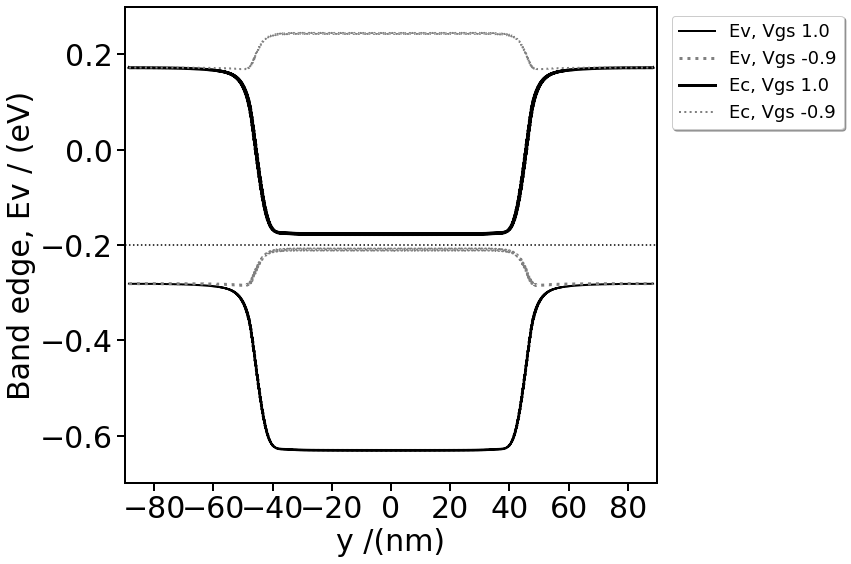

In [19]:
fig, ax = plt.subplots(1,1)
fig.set_size_inches(12,8)


if(PrintFigures):
    f=0 #folder
    i=0 #step 1 to plot bandstructure at
    j=19 # step 2 to plot bandstructure at
    delta=4 
    plt2,pltname = custom_plot_single(fig, ax,
                                     [Y[f][i], Y[f][j],Y[f][i], Y[f][j]], 
                                     [Ev[f][i], Ev[f][j],Ec[f][i], Ec[f][j]],
                                     [r'Ev, Vgs %.1f'%(Vgs[f][i]),r'Ev, Vgs %.1f'%(Vgs[f][j]),
                                      r'Ec, Vgs %.1f'%(Vgs[f][i]),r'Ec, Vgs %.1f'%(Vgs[f][j])],
                                     [-90,90],
                                     [-0.7,0.3],
                                     [r'y /(nm)',
                                      r'Band edge, Ev / (eV)'],
                                     'Ev.png',
                                     ['k','gray','k','gray','b'],
                                     linestyle=['solid','dotted','solid','dotted','solid','solid'],
                                     markertype=[None]*5,
                                     markevery=[1,1,1,1,1],
                                     linewidth=[2,3,3,2,2],
                       show_legend=True,
                       plt_outside=True, y_logscale=False)
    ax.axhline(y = E_f, color = 'k', linestyle = 'dotted')

fig.tight_layout()
#fig.savefig(filename, dpi='figure', format='png', pad_inches=0.1, facecolor='auto', edgecolor='auto')

In [152]:
##### # Function to find the x-value for given y-value
def find_x_for_y(target_y, x_range, f):
    # Define the equation f(x) - target_y = 0
    func = lambda x: f(x) - target_y
    # Use fsolve to find the root, with an initial guess
    x_root, = fsolve(func, np.mean(x_range))
    return x_root

def compute_barrier(U, Vgs, Print=True, Eg=Eg_min):
    num_steps = np.size(Vgs)
    Ev = -Eg/2. + U
    Ec = Eg/2 + U
    Ef = -0.2
    #print(Ev[0][0])
    barrier = np.zeros(num_steps, dtype=float)
    phonon_jump = np.zeros(num_steps, dtype=float)
    
    for j in range(num_steps):
        mid = int(np.shape(Ev)[-1]/2)
        barrier[j] = Ef - Ev[j][mid]
        phonon_jump[j] = Ec[j][mid] - Ef
           # print(Ev[j][0])

    kT_eV = 0.0257025 #eV 1.38e-23*298/1.6e-19    

    f = interp1d(Vgs, barrier, kind='linear', fill_value='extrapolate')      
    a = 5
    b = 8
    #print(factor1*kT_eV, f(factor1*kT_eV))
    # Find x-values where f(x) equals kT_eV and 4*kT_eV
    x_akT_eV = find_x_for_y(a*kT_eV, Vgs, f)
    x_bkT_eV = find_x_for_y(b*kT_eV, Vgs, f)     
    g = interp1d(Vgs, phonon_jump, kind='linear', fill_value='extrapolate')
    x_dot2eV = find_x_for_y(0.2, Vgs, g)

    print('Vgs where barrier is ', a, 'kT:', x_akT_eV)
    print('Vgs where barrier is ', b, 'kT:', x_bkT_eV)
    print('Vgs where phonon-tunneling barrier is 0.2 eV:', x_dot2eV)
    
    import matplotlib.pyplot as plt

    if(Print):   
        fig, ax = plt.subplots(1,1)
        fig.set_size_inches(12,8)
        
        xmin = Vgs[-1] - 0.1
        xmax = Vgs[0] + 0.1
        ymin = np.min(barrier)
        ymax = np.max(phonon_jump)
        plt,pltname = custom_plot_single(fig, ax,
                                         [Vgs, Vgs],
                                         [barrier, phonon_jump],
                                         [r'Transport barrier', r'Phonon-tunneling barrier'] 
                                         + [None for s in range(num_steps)],
                                         [xmin,xmax],
                                         [ymin,ymax],
                                         [r'Vgs / (V)',
                                          r'Barrier / (eV)'],
                                         'Barrier.png',
                                         color = ['k','r'],
                                         linestyle=['solid','solid'],
                                         markertype=[None,None],
                                         markevery=[1,1,1,1,1,1,1,1,1,1,1,1],
                                         linewidth=[1,1,1,1,1,1,1,1,1,1,1,3,3],
                                         fillstyle=['none','none','none','none','none','none','none','none','none','none','none','none','none','none'],                                     
                                         show_legend=True,
                                         plt_outside=True, y_logscale=False) 
        

    
        ax.plot([xmin,x_akT_eV], [a*kT_eV,a*kT_eV], color='k', linestyle='--')     
        ax.plot([xmin,x_bkT_eV], [b*kT_eV,b*kT_eV], color='k', linestyle='--')     
    
        ax.plot([x_akT_eV,x_akT_eV], [ymin,a*kT_eV], color='k', linestyle='--')     
        ax.plot([x_bkT_eV,x_bkT_eV], [ymin,b*kT_eV], color='k', linestyle='--')     
        ax.plot([x_dot2eV,x_dot2eV], [ymin,0.2], color='r', linestyle='--')     
        ax.plot([xmin,x_dot2eV], [0.2,0.2], color='r', linestyle='--')     
        
        plt.savefig(pltname, bbox_inches = "tight", dpi='figure', format='png', pad_inches=0.1, facecolor='auto', edgecolor='auto')
        
    return x_akT_eV, x_bkT_eV, x_dot2eV

In [153]:
def log_interp(Vgs, Ids, at_Vgs):

    # Log-transform the Ids
    log_Ids = np.log(Ids)
    
    # Create a linear interpolation function on the log-transformed data
    log_interp = interp1d(Vgs, log_Ids, kind='linear')
    
    # Interpolate to find the log of the interpolated value at at_Vgs
    log_interpolated_value = log_interp(at_Vgs)
    
    # Exponentiate to get back to the original scale
    interpolated_value = np.exp(log_interpolated_value)
    
    return interpolated_value


def compute_SS(Vgs, G, at_numer_Vgs, at_denom_Vgs, Print=True):
    Vds=0.1 #[V]
    G_0 = 7.748091729e-5 #[S]
    Scaling_Factor = Vds*G_0
    
    Ids = Scaling_Factor*G
    #print('\nVgs:', Vgs)
    #print('Ids:', Ids)
    dVg = at_denom_Vgs - at_numer_Vgs
    dlogI = np.log10(log_interp(Vgs, Ids, at_numer_Vgs)/log_interp(Vgs, Ids, at_denom_Vgs))
    SS = dVg*1e3/dlogI #mV/decade
    print('\tSS (mV/decade):', SS)

    return SS


No trap:

	ON current / (1e-4 \mu A) 1.188449961976954
Vgs where barrier is  5 kT: 0.08599382221093703
Vgs where barrier is  8 kT: 0.17862321651030055
Vgs where phonon-tunneling barrier is 0.2 eV: 0.23162400410622905
	SS (mV/decade): 71.34258977080837


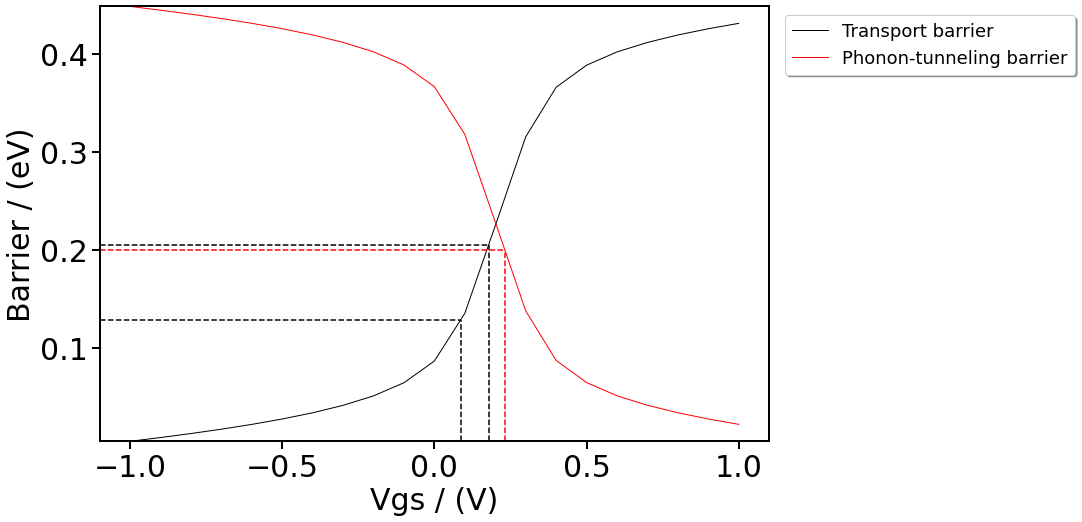

In [154]:
print('\nNo trap:')
I_ON_notrap = Scaling_Factor*G[0][pts[0]-1]
print('\n\tON current / (1e-4 \mu A)', I_ON_notrap*1e10)
vgs_at_akT, vgs_at_bkT, vgs_at_phononBarrier = compute_barrier(U[0][:pts[folder]], Vgs[0][:pts[folder]], True) #avg
SS_notrap = compute_SS(Vgs[0][:pts[0]], G[0][:pts[0]], vgs_at_akT, vgs_at_bkT, True)


In [35]:
I_ON_3D =  np.zeros(end_3D-start_3D+1,dtype=float)
SS_3D =  np.zeros(end_3D-start_3D+1,dtype=float)
I_ON_2D =  np.zeros(end_2D-end_3D+1,dtype=float)
SS_2D =  np.zeros(end_2D-end_3D+1,dtype=float)

I_ON_3D[0] = I_ON_notrap
I_ON_2D[0] = I_ON_notrap
SS_3D[0] = SS_notrap
SS_2D[0] = SS_notrap

print(SS_3D.shape, rhop_3D.shape)
print(SS_2D.shape, rhop_2D.shape)

(8,) (8,)
(9,) (9,)


In [37]:
print('\n3D stats:')
counter=1
for folder in range(start_3D, end_3D):
    I_ON_3D[counter] = Scaling_Factor*G[folder][pts[folder]-1]
    print('\n\tON current / (1e-4 \mu A)', I_ON_3D[counter]*1e10)
    vgs_at_akT, vgs_at_bkT, vgs_at_phononBarrier = compute_barrier(U[folder][:pts[folder]], Vgs[folder][:pts[folder]], False) #avg
    SS_3D[counter] = compute_SS(Vgs[folder][:pts[folder]], G[folder][:pts[folder]], vgs_at_akT, vgs_at_bkT, True)
    counter += 1
    
print('\n2D stats:')
counter=1
for folder in range(end_3D, end_2D):
    I_ON_2D[counter] = Scaling_Factor*G[folder][pts[folder]-1]
    print('\n\tON current / (1e-4 \mu A):', I_ON_2D[counter]*1e10)    
    vgs_at_akT, vgs_at_bkT, vgs_at_phononBarrier = compute_barrier(U[folder][:pts[folder]], Vgs[folder][:pts[folder]], False) #avg    
    SS_2D[counter] = compute_SS(Vgs[folder][:pts[folder]], G[folder][:pts[folder]], vgs_at_akT, vgs_at_bkT, True)
    counter += 1


3D stats:

	ON current / (1e-4 \mu A) 1.4060331106953274
Vgs where barrier is  5 kT: 0.007338161724500598
Vgs where barrier is  8 kT: 0.1170059983353341
Vgs where phonon-tunneling barrier is 0.2 eV: 0.17523498116563987
	SS (mV/decade): 86.88559754029463

	ON current / (1e-4 \mu A) 1.5306300646613238
Vgs where barrier is  5 kT: -0.07953867653694556
Vgs where barrier is  8 kT: 0.04567076241561741
Vgs where phonon-tunneling barrier is 0.2 eV: 0.11483378646760067
	SS (mV/decade): 103.11447544350119

	ON current / (1e-4 \mu A) 1.598653217399493
Vgs where barrier is  5 kT: -0.13205759041549234
Vgs where barrier is  8 kT: -0.0032036763797903727
Vgs where phonon-tunneling barrier is 0.2 eV: 0.07045624311490335
	SS (mV/decade): 113.19675719891295

	ON current / (1e-4 \mu A) 1.5742297529783065
Vgs where barrier is  5 kT: -0.2679910189615109
Vgs where barrier is  8 kT: -0.10745678243383544
Vgs where phonon-tunneling barrier is 0.2 eV: -0.020023400756921286
	SS (mV/decade): 133.85527333685678

	O

In [96]:
print('GS voltage range', Vgs[1])
print('last valid voltage', Vgs[1,pts[1]-1])
print('last sixth valid voltage is -1 V', Vgs[1,pts[1]-6])
# So we use -6 in the fractional_charge_3D[:,-6] below while defining y2_lst

GS voltage range [ 0.5    0.395  0.29   0.185  0.08  -0.025 -0.13  -0.235 -0.34  -0.445
 -0.55  -0.655 -0.76  -0.865 -0.97  -1.075 -1.18  -1.285 -1.39  -1.495
 -1.6    0.     0.     0.     0.     0.     0.     0.     0.     0.
  0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
  0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
  0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
  0.     0.     0.     0.   ]
last valid voltage -1.6
last sixth valid voltage is -1 V -1.075


/tmp/ipykernel_1808314/3980224056.py:87: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  plt.savefig(pltname, bbox_inches="tight", dpi='figure', format='png', pad_inches=0.1,
/usr/lib/python3/dist-packages/IPython/core/pylabtools.py:151: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


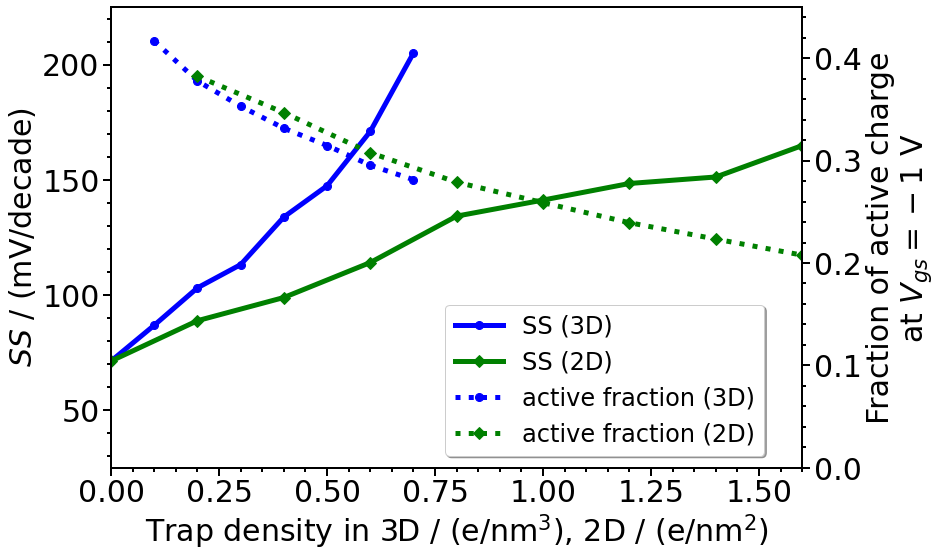

In [160]:
# Create the figure and axis
#fig, ax1 = plt.subplots(1, 1, figsize=(10, 7))  # Size of the figure
#fig = plt.figure(figsize=(12,8), constrained_layout=True)
fig = plt.figure(figsize=(12,8), constrained_layout=True)
ax1 = fig.add_axes([0.18,0.15,0.8,0.8])

custom_ls_pattern=(0, (3, 2, 1, 2, 1, 2))
fig.patch.set_facecolor('white')
ax1.patch.set_facecolor('white')
# Plotting for 3D and 2D data
x_lst = [rhop_3D, rhop_2D]
y_lst = [SS_3D, SS_2D]
label_lst = ['SS (3D)', 'SS (2D)']
color = ['b', 'g']
linestyle = [None, None]
markertype = ['o', 'D']
fillstyle = ['full', 'full']
linewidth = [5, 5]
markevery = [1, 1]

# Plot each line on the primary y-axis
for p in range(len(x_lst)):
    ax1.plot(x_lst[p], y_lst[p], color=color[p], linewidth=linewidth[p],
             linestyle=linestyle[p], marker=markertype[p], fillstyle=fillstyle[p],
             markevery=markevery[p], markersize=8, label=label_lst[p])

#ax1.legend(prop={'size': 24}, loc='best')

ax1.tick_params(which='minor', width=2, length=4, color='k')
ax1.tick_params(which='major', width=2, length=8, color='k')

ax1.set_xlim(0, 1.6)  # X-axis limit
ax1.set_ylim(25, 225)  # Y-axis limit for the primary y-axis (ax1)

ax1.set_xlabel(r'Trap density in 3D / (e/nm$^3$), 2D / (e/nm$^{2}$)', fontsize=30)
ax1.set_ylabel(r'$SS$ / (mV/decade)', fontsize=30)  # Primary y-axis label

for spine in ax1.spines.values():
    spine.set_linewidth(2)

ax1.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax1.yaxis.set_minor_locator(ticker.AutoMinorLocator())



ax2 = ax1.twinx()  # Create a second y-axis sharing the same x-axis
x2_lst = [rhop_3D[1:], rhop_2D[1:]]
y2_lst = [fractional_charge_3D[:,-6], fractional_charge_2D[:,-6]]  
linestyle2 = ['dotted', 'dotted']
label_lst2 = ['active fraction (3D)', 'active fraction (2D)']

#y2_lst = [np.insert(fractional_charge_3D[:,-1],0,1), np.insert(fractional_charge_2D[:,-1],0,1)]  

for p in range(len(x_lst)):
    ax2.plot(x2_lst[p], y2_lst[p], color=color[p], linewidth=linewidth[p],
             linestyle=linestyle2[p], marker=markertype[p], fillstyle=fillstyle[p],
             markevery=markevery[p], markersize=8, label=label_lst2[p], alpha=1)  # alpha for transparency

#ax2.legend(prop={'size': 24}, loc='best')

ax2.tick_params(which='minor', width=2, length=4, color='k')
ax2.tick_params(which='major', width=2, length=8, color='k')

ax2.set_ylim(0, 0.45)  
ax2.set_ylabel(r'Fraction of active charge'+'\n'+'at $V_{gs}=-1$ V', fontsize=30)  
    
for spine in ax2.spines.values():
    spine.set_linewidth(2)

ax2.yaxis.set_minor_locator(ticker.AutoMinorLocator())


#legends
# Get the handles and labels for both axes
handles, labels = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

# Combine the handles and labels
handles += handles2
labels += labels2

# Create a single legend for both axes with a fixed location
fig.legend(handles, labels, loc='lower right', prop={'size': 24}, bbox_to_anchor=(,shadow=True0.95,0.15))


pltname = 'densityVar_3D_2D_SS_fraction.png'
plt.savefig(pltname, bbox_inches="tight", dpi='figure', format='png', pad_inches=0.1, 
            facecolor='white', edgecolor='auto')

plt.show()
